# Task Log CSV Analysis

This notebook analyzes task-level metrics such as success rate, steps, and latency from a CSV file.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
plt.style.use("ggplot")

In [2]:
# Update this path if you want to analyze a different CSV file.
CSV_PATH = Path("/work/csv/libero/initial/libero90/2026-04-18_16-22-30/task_log.csv")

if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV file not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
print(f"Loaded: {CSV_PATH}")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
df.head()

Loaded: /work/csv/libero/initial/libero90/2026-04-18_16-22-30/task_log.csv
Rows: 10, Columns: 7


,task_id,task_description,success_rate,steps_mean,steps_std,latency_mean_ms,latency_std_ms
0,0,pick up the alphabet soup and place it in the basket,0.96,166.54,35.604612,81.794081,3.942811
1,1,pick up the cream cheese and place it in the basket,0.98,143.22,26.619008,81.204349,4.025652
2,2,pick up the salad dressing and place it in the basket,0.96,138.02,32.906224,81.065679,3.997675
3,3,pick up the bbq sauce and place it in the basket,0.98,149.04,27.924871,81.170610,4.027393
4,4,pick up the ketchup and place it in the basket,1.00,155.20,16.763055,80.996025,4.032933


In [3]:
required_columns = [
    "task_id",
    "task_description",
    "success_rate",
    "steps_mean",
    "steps_std",
    "latency_mean_ms",
    "latency_std_ms",
]

missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

numeric_cols = ["success_rate", "steps_mean", "steps_std", "latency_mean_ms", "latency_std_ms"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

print("Column validation passed.")
df[numeric_cols].isna().sum().to_frame("nan_count")

Column validation passed.


Column validation passed.


,nan_count
success_rate,0
steps_mean,0
steps_std,0
latency_mean_ms,0
latency_std_ms,0


In [4]:
summary = {
    "num_tasks": len(df),
    "avg_success_rate": df["success_rate"].mean(),
    "median_success_rate": df["success_rate"].median(),
    "avg_steps": df["steps_mean"].mean(),
    "avg_latency_ms": df["latency_mean_ms"].mean(),
    "avg_latency_std_ms": df["latency_std_ms"].mean(),
}

summary_df = pd.DataFrame([summary]).T.rename(columns={0: "value"})
summary_df["value"] = summary_df["value"].astype(float).round(4)
summary_df

,value
num_tasks,10.0000
avg_success_rate,0.9800
median_success_rate,0.9800
avg_steps,151.8780
avg_latency_ms,81.2268
avg_latency_std_ms,3.9783


In [5]:
metric_cols = ["success_rate", "steps_mean", "steps_std", "latency_mean_ms", "latency_std_ms"]
df[metric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
success_rate,10.0,0.980000,0.016330,0.960000,0.965000,0.980000,0.995000,1.000000
steps_mean,10.0,151.878000,11.859846,137.780000,142.170000,151.190000,162.235000,169.240000
steps_std,10.0,25.277632,8.271912,9.397212,21.217868,26.678981,31.660886,35.604612
latency_mean_ms,10.0,81.226827,0.451765,80.633058,81.013439,81.187479,81.425286,82.044093
latency_std_ms,10.0,3.978323,0.094425,3.778824,3.945105,4.011664,4.031548,4.078296


In [6]:
top_success = df.sort_values("success_rate", ascending=False).head(10)[
    ["task_id", "task_description", "success_rate", "latency_mean_ms", "steps_mean"]
]

slowest = df.sort_values("latency_mean_ms", ascending=False).head(10)[
    ["task_id", "task_description", "latency_mean_ms", "success_rate", "steps_mean"]
]

print("Top tasks by success_rate")
display(top_success)
print("\nSlowest tasks by latency_mean_ms")
display(slowest)

Top tasks by success_rate


Top tasks by success_rate


,task_id,task_description,success_rate,latency_mean_ms,steps_mean
7,7,pick up the milk and place it in the basket,1.00,80.633058,141.82
4,4,pick up the ketchup and place it in the basket,1.00,80.996025,155.20
8,8,pick up the chocolate pudding and place it in the basket,1.00,81.491578,169.24
1,1,pick up the cream cheese and place it in the basket,0.98,81.204349,143.22
6,6,pick up the butter and place it in the basket,0.98,82.044093,164.58
3,3,pick up the bbq sauce and place it in the basket,0.98,81.170610,149.04
9,9,pick up the orange juice and place it in the basket,0.98,81.226407,137.78
0,0,pick up the alphabet soup and place it in the basket,0.96,81.794081,166.54
5,5,pick up the tomato sauce and place it in the basket,0.96,80.642392,153.34
2,2,pick up the salad dressing and place it in the basket,0.96,81.065679,138.02



Slowest tasks by latency_mean_ms


,task_id,task_description,latency_mean_ms,success_rate,steps_mean
6,6,pick up the butter and place it in the basket,82.044093,0.98,164.58
0,0,pick up the alphabet soup and place it in the basket,81.794081,0.96,166.54
8,8,pick up the chocolate pudding and place it in the basket,81.491578,1.00,169.24
9,9,pick up the orange juice and place it in the basket,81.226407,0.98,137.78
1,1,pick up the cream cheese and place it in the basket,81.204349,0.98,143.22
3,3,pick up the bbq sauce and place it in the basket,81.170610,0.98,149.04
2,2,pick up the salad dressing and place it in the basket,81.065679,0.96,138.02
4,4,pick up the ketchup and place it in the basket,80.996025,1.00,155.20
5,5,pick up the tomato sauce and place it in the basket,80.642392,0.96,153.34
7,7,pick up the milk and place it in the basket,80.633058,1.00,141.82


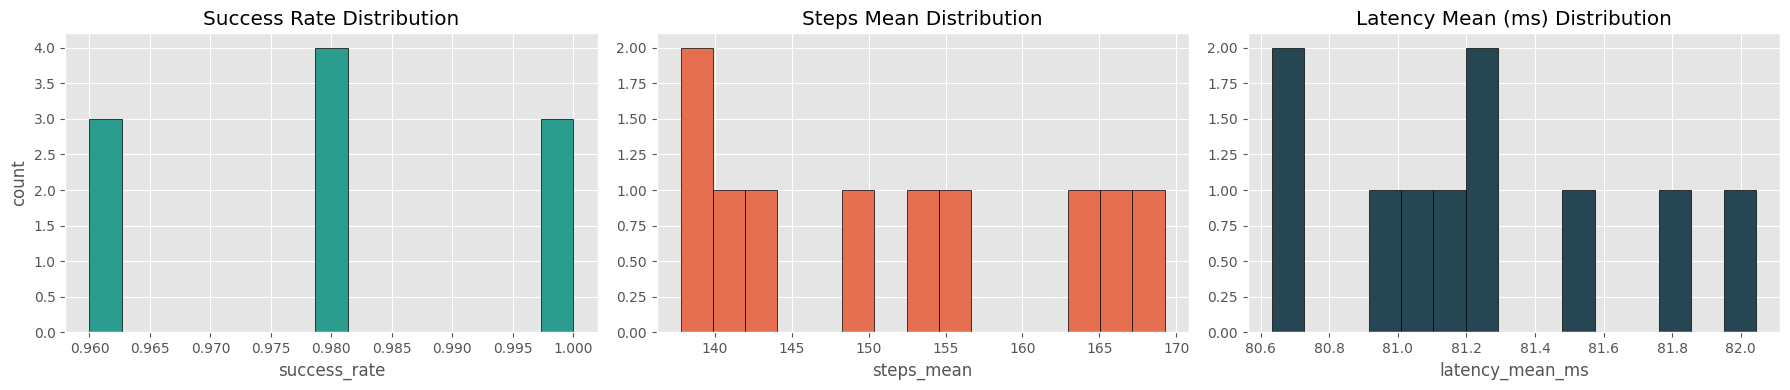

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df["success_rate"].dropna(), bins=15, color="#2a9d8f", edgecolor="black")
axes[0].set_title("Success Rate Distribution")
axes[0].set_xlabel("success_rate")
axes[0].set_ylabel("count")

axes[1].hist(df["steps_mean"].dropna(), bins=15, color="#e76f51", edgecolor="black")
axes[1].set_title("Steps Mean Distribution")
axes[1].set_xlabel("steps_mean")

axes[2].hist(df["latency_mean_ms"].dropna(), bins=15, color="#264653", edgecolor="black")
axes[2].set_title("Latency Mean (ms) Distribution")
axes[2].set_xlabel("latency_mean_ms")

plt.tight_layout()
plt.show()

In [8]:
corr = df[["success_rate", "steps_mean", "latency_mean_ms", "latency_std_ms"]].corr()
corr

,success_rate,steps_mean,latency_mean_ms,latency_std_ms
success_rate,1.000000,0.095925,-0.114914,0.381379
steps_mean,0.095925,1.000000,0.627092,0.292543
latency_mean_ms,-0.114914,0.627092,1.000000,0.638315
latency_std_ms,0.381379,0.292543,0.638315,1.000000


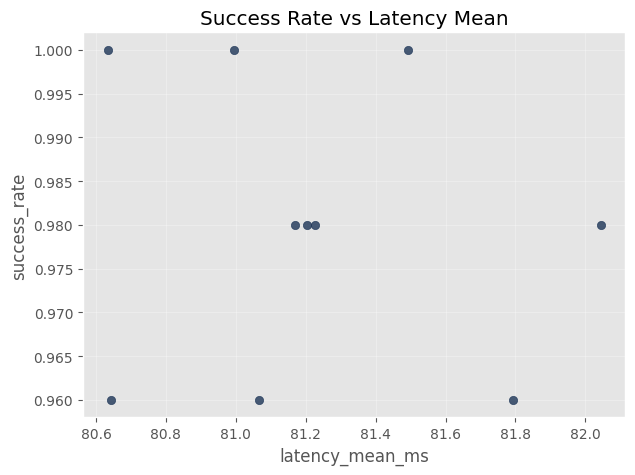

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(df["latency_mean_ms"], df["success_rate"], alpha=0.8, color="#1d3557")
plt.title("Success Rate vs Latency Mean")
plt.xlabel("latency_mean_ms")
plt.ylabel("success_rate")
plt.grid(True, alpha=0.3)
plt.show()